## **Time series forecasting model using Long Short-Term Memory (LSTM) neural networks**

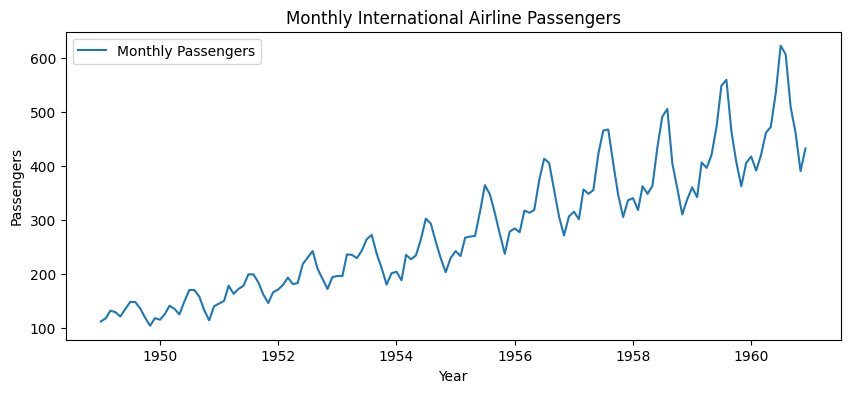

Epoch 1/150


/usr/local/lib/python3.11/dist-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


14/14 ━━━━━━━━━━━━━━━━━━━━ 3s 37ms/step - loss: 0.0705 - val_loss: 0.0225
Epoch 2/150
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.0099 - val_loss: 0.0249
Epoch 3/150
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0073 - val_loss: 0.0297
Epoch 4/150
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0114 - val_loss: 0.0221
Epoch 5/150
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.0089 - val_loss: 0.0228
Epoch 6/150
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0065 - val_loss: 0.0218
Epoch 7/150
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0065 - val_loss: 0.0218
Epoch 8/150
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.0076 - val_loss: 0.0215
Epoch 9/150
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.0067 - val_loss: 0.0221
Epoch 10/150
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0067 - val_loss: 0.0222
Epoch 11/150
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.0092 - val_loss: 0.0213
Epoch 12/150
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0

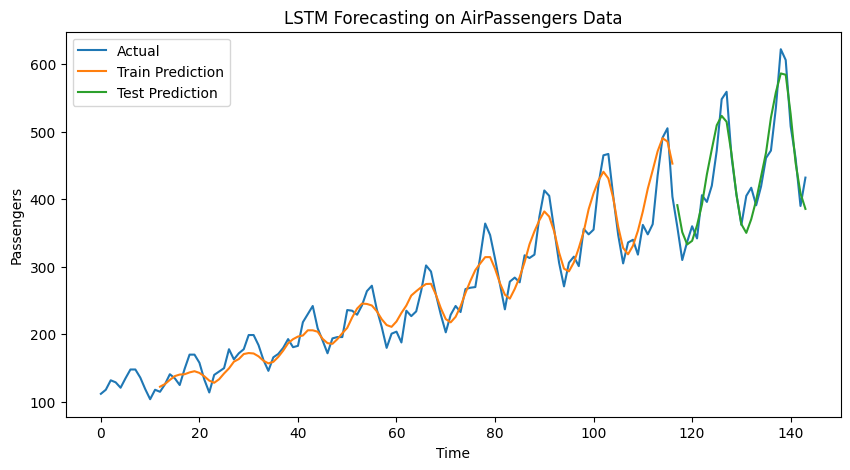

In [58]:
# Step 1: Import Libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping
import math

# Step 2: Load the dataset
df = pd.read_csv('AirPassengers.csv')
df.columns = ['Month', 'Passengers']
df['Month'] = pd.to_datetime(df['Month'])
df.set_index('Month', inplace=True)

# Plot the original data
plt.figure(figsize=(10, 4))
plt.plot(df, label='Monthly Passengers')
plt.title("Monthly International Airline Passengers")
plt.xlabel("Year")
plt.ylabel("Passengers")
plt.legend()
plt.show()

# Step 3: Normalize the dataset
scaler = MinMaxScaler(feature_range=(0, 1))
data_scaled = scaler.fit_transform(df)

# Step 4: Create sequences
def create_dataset(dataset, time_step=12):
    X, Y = [], []
    for i in range(len(dataset) - time_step):
        X.append(dataset[i:i+time_step, 0])
        Y.append(dataset[i + time_step, 0])
    return np.array(X), np.array(Y)

time_step = 12
X, y = create_dataset(data_scaled, time_step)
X = X.reshape(X.shape[0], X.shape[1], 1)

# Step 5: Split into training and testing sets
train_size = int(len(X) * 0.8)
X_train, X_test = X[:train_size], X[train_size:]
y_train, y_test = y[:train_size], y[train_size:]

# Step 6: Build the LSTM model
model = Sequential()
model.add(LSTM(units=50, input_shape=(time_step, 1)))
model.add(Dropout(0.2))
model.add(Dense(1))
model.compile(optimizer='adam', loss='mean_squared_error')

# Step 7: Train the model
early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
history = model.fit(X_train, y_train, validation_data=(X_test, y_test),
                    epochs=150, batch_size=8, verbose=1, callbacks=[early_stop])

# Step 8: Make predictions
train_predict = model.predict(X_train)
test_predict = model.predict(X_test)

# Inverse transform predictions
train_predict = scaler.inverse_transform(train_predict)
test_predict = scaler.inverse_transform(test_predict)
y_train_inv = scaler.inverse_transform(y_train.reshape(-1, 1))
y_test_inv = scaler.inverse_transform(y_test.reshape(-1, 1))

# Step 9: Calculate RMSE
train_rmse = math.sqrt(mean_squared_error(y_train_inv, train_predict))
test_rmse = math.sqrt(mean_squared_error(y_test_inv, test_predict))
print(f"Train RMSE: {train_rmse:.2f}")
print(f"Test RMSE: {test_rmse:.2f}")

# Step 10: Plot predictions vs actual
train_plot = np.empty_like(data_scaled)
train_plot[:, :] = np.nan
train_plot[time_step:len(train_predict)+time_step, 0] = train_predict[:, 0]

test_plot = np.empty_like(data_scaled)
test_plot[:, :] = np.nan
test_plot[len(train_predict)+(time_step):, 0] = test_predict[:, 0]

plt.figure(figsize=(10, 5))
plt.plot(scaler.inverse_transform(data_scaled), label='Actual')
plt.plot(train_plot, label='Train Prediction')
plt.plot(test_plot, label='Test Prediction')
plt.title('LSTM Forecasting on AirPassengers Data')
plt.xlabel('Time')
plt.ylabel('Passengers')
plt.legend()
plt.show()

Model Evaluation

In [59]:
train_r2 = r2_score(y_train_inv, train_predict)
test_r2  = r2_score(y_test_inv,  test_predict)
print(f"Train R²: {train_r2:.4f}")
print(f"Test  R²: {test_r2:.4f}")


Train R²: 0.9379
Test  R²: 0.8518


Forecast future passengers

In [60]:
def forecast_future(model, data_scaled, scaler, time_step=12, n_future=12):
    """Returns an array of length n_future with forecasted (inverse-scaled) passenger counts."""
    # take the last `time_step` points from the scaled data as the seed
    last_seq = data_scaled[-time_step:].reshape(1, time_step, 1)
    preds_scaled = []
    for _ in range(n_future):
        # predict next point
        next_scaled = model.predict(last_seq)[0,0]
        preds_scaled.append(next_scaled)
        # update the sequence: drop oldest, append newest
        last_seq = np.concatenate(
            [last_seq[:,1:,:], [[ [next_scaled] ]]], axis=1
        )
    # inverse transform back to original scale
    preds = scaler.inverse_transform(np.array(preds_scaled).reshape(-1, 1))
    return preds.flatten()

# Example: forecast the next 12 months
n_future = 12
future_preds = forecast_future(model, data_scaled, scaler, time_step, n_future)

# Print the forecasts
for i, p in enumerate(future_preds, 1):
    print(f"Month +{i}: {p:.0f} passengers")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
Month +1: 396 passengers
Month +2: 407 passengers
Month +3: 450 passengers
Month +4: 508 passengers
Month +5: 571 passengers
Month +6: 636 passengers
Month +7: 673 passengers
Month +8: 643 passengers
Month +9: 558 passengers
Month +10: 468 passengers
Month +11: 393 passengers
Month +12: 364 passengers


# Historical + forecast Plot

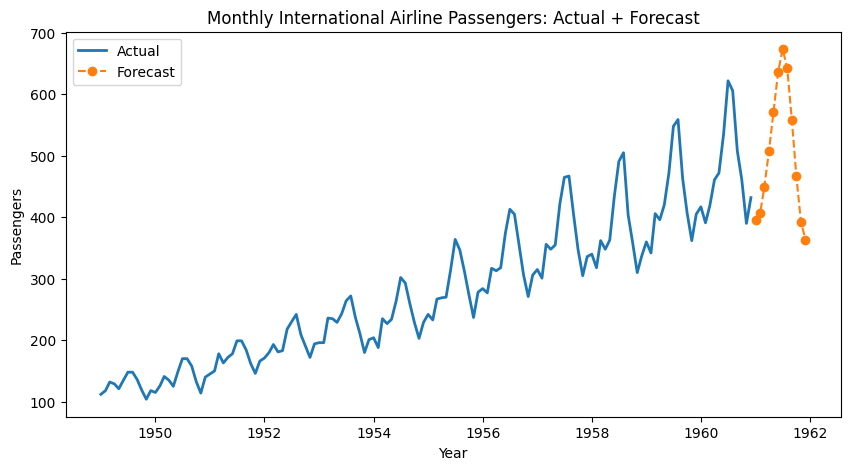

In [64]:
# build a datetime index for the forecast
last_date = df.index[-1]
future_index = pd.date_range(start=last_date + pd.offsets.MonthBegin(),
                             periods=n_future, freq='MS')

plt.figure(figsize=(10, 5))
# historical
plt.plot(df.index, df['Passengers'], label='Actual', linewidth=2)
# forecast
plt.plot(future_index, future_preds, label='Forecast', linestyle='--', marker='o')
plt.title('Monthly International Airline Passengers: Actual + Forecast')
plt.xlabel('Year')
plt.ylabel('Passengers')
plt.legend()
plt.show()